# 🌊 Análisis Global de Riesgo de Terremotos y Tsunamis (2001–2022)

---

## 🧩 1. Contexto del Proyecto

Los terremotos y tsunamis representan algunos de los fenómenos naturales más destructivos del planeta.  
A lo largo de las últimas décadas, eventos como el **tsunami del Océano Índico en 2004** y el de **Japón en 2011** han causado miles de muertes y pérdidas económicas incalculables.  

En respuesta, la **ciencia de datos** ha surgido como una herramienta poderosa para analizar grandes volúmenes de información sísmica y predecir el potencial de un tsunami a partir de los parámetros de un terremoto.

El conjunto de datos **Global Earthquake–Tsunami Risk Assessment Dataset (2001–2022)** reúne **782 registros de terremotos significativos (magnitud ≥ 6.5)** en todo el mundo.  
Este dataset permite estudiar patrones sísmicos, evaluar riesgos y desarrollar **modelos predictivos** que apoyen los **sistemas de alerta temprana**.

A pesar de los avances en monitoreo y predicción, aún existe gran incertidumbre sobre **qué terremotos tienen el potencial de generar tsunamis**, ya que no todos los sismos de gran magnitud producen olas destructivas.  
Identificar los factores que diferencian ambos tipos de eventos es clave para reducir el impacto de futuros desastres naturales.

---

## ❓ 2. Planteamiento del Problema

> **¿Qué características sísmicas permiten predecir con mayor precisión si un terremoto tiene el potencial de generar un tsunami?**

Esta pregunta busca determinar qué variables —como la magnitud, la profundidad, la localización geográfica o el tipo de falla— están más asociadas con la probabilidad de que un evento sísmico produzca un tsunami.

---

## 🎯 3. Objetivos del Análisis

### Objetivo general:
Desarrollar un **cuaderno de Jupyter** que permita analizar datos sísmicos y construir un **modelo predictivo** capaz de estimar la **probabilidad de generación de tsunamis** a partir de las características de los terremotos registrados entre 2001 y 2022..

### Objetivos específicos:
- Realizar un **análisis exploratorio de datos (EDA)** del conjunto de terremotos registrados entre 2001 y 2022.  
- Evaluar la **distribución y correlación** de las principales variables sísmicas (magnitud, profundidad, intensidad, localización).  
- Identificar las **variables más influyentes** en la ocurrencia de tsunamis.  
- Construir y evaluar **modelos predictivos de clasificación binaria** (tsunami / no tsunami).  
- Visualizar las **tendencias y patrones temporales** de los eventos.  
- Formular **conclusiones y recomendaciones** basadas en los hallazgos obtenidos.

---

## 🔁 4. Ciclo del Análisis de Datos

Etapas principales del proceso:

1. **Obtención de datos:** recopilación del conjunto global de registros sísmicos.  
2. **Limpieza y preparación:** manejo de valores nulos, normalización y codificación de variables.  
3. **Exploración:** análisis descriptivo y visualización de distribuciones.  
4. **Modelado predictivo:** entrenamiento de modelos de clasificación (p. ej., regresión logística, árbol de decisión, random forest).  
5. **Evaluación:** métricas de desempeño como precisión, recall, F1-score y matriz de confusión.  
6. **Comunicación:** visualización de resultados y conclusiones.



 # ==============================================
# 🧮 5. Carga y Visualización de Datos
# ==============================================

In [1]:
!pip install folium

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías geoespaciales y de visualización interactiva
import folium
from matplotlib import cm, colors

# Librerías para modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.tree import DecisionTreeClassifier


# Cargar dataset local (CAMBIAR NOMBRE DEL ARCHIVO)
df = pd.read_csv("D:\\earthquake_data_tsunami.csv")   

df.head()


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


### 📌 Descripción detallada de las variables del dataset
#### **1. magnitude**  
**Qué es:** Magnitud del terremoto en la escala de Richter o Mw.  
**Rango:** 6.5 – 9.1  
**Importancia:** ⭐⭐⭐⭐⭐ **Alta**  
La magnitud es el principal predictor de tsunamis: sismos más fuertes desplazan más volumen de agua.

---

#### **2. cdi**  
**Qué es:** *Community Decimal Intensity* → intensidad percibida por la población.  
**Rango:** 0 – 9  
**Importancia:** ⭐⭐⭐ ☆☆ **Media**  
Sirve para medir el impacto en comunidades, pero no es directamente indicador de tsunami.

---

#### **3. mmi**  
**Qué es:** *Modified Mercalli Intensity* → intensidad instrumental que refleja daños estructurales.  
**Rango:** 1 – 9  
**Importancia:** ⭐⭐⭐ ☆☆ **Media**  
Describe la fuerza del movimiento en superficie, contribuye pero no determina el riesgo de tsunami.

---

#### **4. sig**  
**Qué es:** *Significance score* → puntaje global del evento según USGS.  
**Rango:** 650 – 2910  
**Importancia:** ⭐⭐⭐⭐⭐ **Alta**  
Resume varios factores del sismo: magnitud, población expuesta, daños… eventos significativos tienen mayor probabilidad de producir tsunamis.

---

#### **5. nst**  
**Qué es:** Número de estaciones sísmicas que registraron el evento.  
**Rango:** 0 – 934  
**Importancia:** ⭐⭐ ☆☆☆ **Baja**  
Refleja calidad de datos, pero no afecta físicamente el riesgo de tsunami.

---

#### **6. dmin**  
**Qué es:** Distancia (en grados) a la estación sísmica más cercana.  
**Rango:** 0.0 – 17.7  
**Importancia:** ⭐⭐ ☆☆☆ **Baja**  
Indica precisión de localización, no riesgo de tsunami.

---

#### **7. gap**  
**Qué es:** *Azimuthal gap*, un indicador de la cobertura de estaciones.  
**Rango:** 0.0 – 239.0  
**Importancia:** ⭐⭐ ☆☆☆ **Baja**  
Valores altos significan menor fiabilidad en la ubicación del epicentro.

---

#### **8. depth**  
**Qué es:** Profundidad del hipocentro en km.  
**Rango:** 2.7 – 670.8  
**Importancia:** ⭐⭐⭐⭐⭐ **Alta**  
Los terremotos **superficiales** (≤ 70 km) son los que **pueden generar tsunamis**, ya que desplazan el fondo marino.

---

#### **9. latitude**  
**Qué es:** Latitud geográfica del epicentro.  
**Rango:** -61.85° – 71.63°  
**Importancia:** ⭐⭐⭐⭐⭐ **Alta**  
Permite identificar si el sismo ocurrió en zonas oceánicas o costeras, fundamentales para el riesgo de tsunami.

---

#### **10. longitude**  
**Qué es:** Longitud geográfica del epicentro.  
**Rango:** -179.97° – 179.66°  
**Importancia:** ⭐⭐⭐⭐⭐ **Alta**  
Junto con la latitud, indica cercanía al mar y ubicación respecto a fallas tectónicas.

---

#### **11. Year**  
**Qué es:** Año del evento.  
**Rango:** 2001 – 2022  
**Importancia:** ⭐⭐⭐ ☆☆ **Media**  
Permite analizar tendencias, ciclos sísmicos y distribución temporal.

---

#### **12. Month**  
**Qué es:** Mes del evento.  
**Rango:** 1 – 12  
**Importancia:** ⭐⭐ ☆☆☆ **Baja**  
No existe relación científica fuerte entre mes del año y tsunamis, pero sirve para analizar patrones estacionales.

---

#### **13. tsunami**  
**Qué es:** Variable objetivo (target).  
**Valores:** 0 = No hubo tsunami, 1 = Sí hubo tsunami.  
**Importancia:** ⭐⭐⭐⭐⭐ **Máxima**  
Es la variable que intentamos predecir usando machine learning.


 # ==============================================
# 🧹 6. Limpieza y Preparación de Datos
# ==============================================

In [3]:

print("Información general del dataset:")
print(df.info())

print("\nValores nulos:")
print(df.isnull().sum())

# Eliminamos filas con datos faltantes (si es necesario)
df = df.dropna()

print("\nDescripción estadística:")
display(df.describe())


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB
None

Valores nulos:
magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami   

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


# ==========================================
# 🔍 7. Análisis Exploratorio de Datos 
# ==========================================

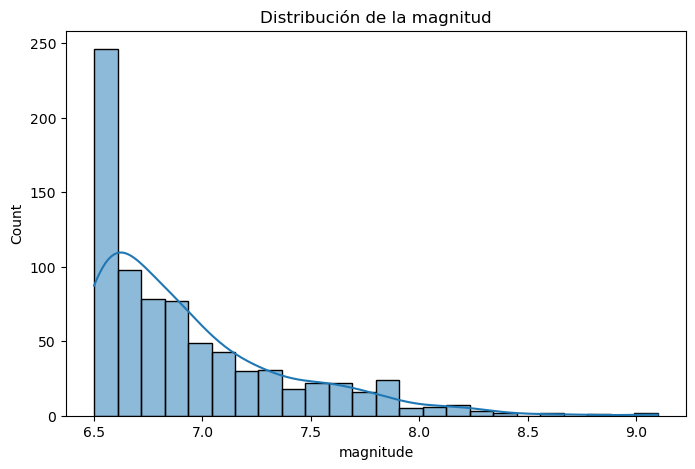

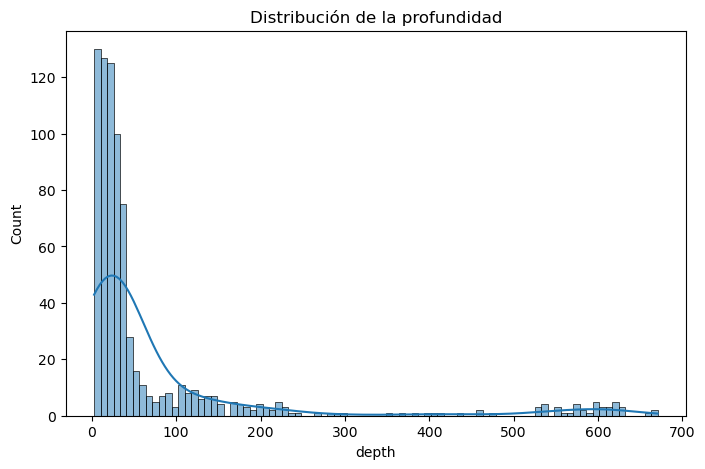

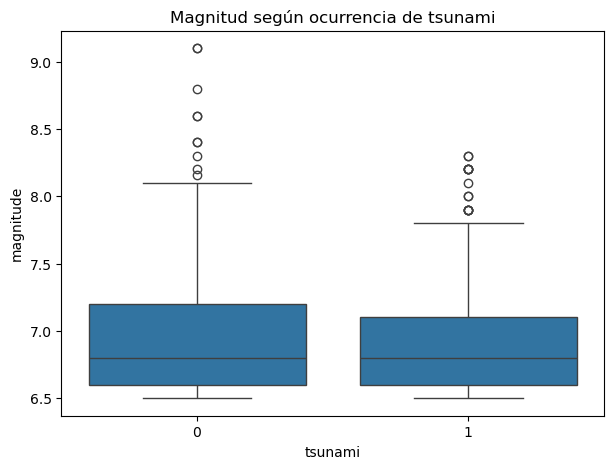

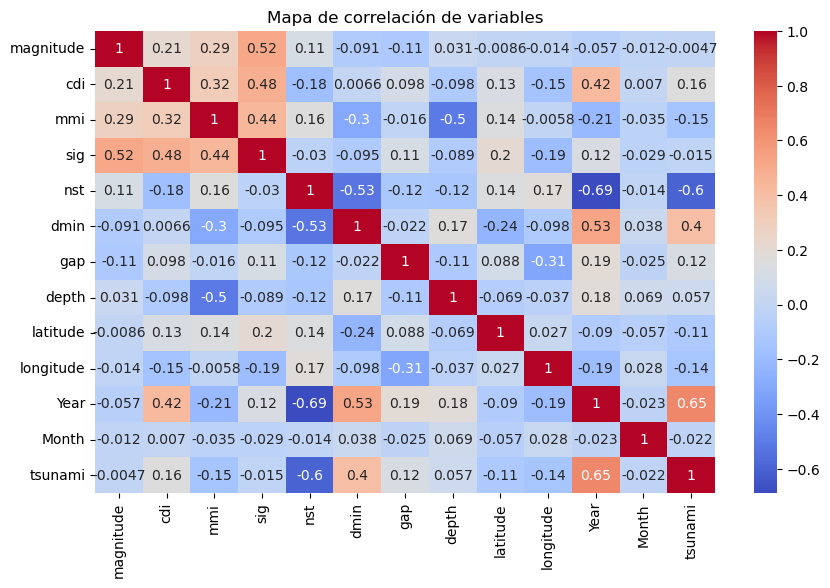

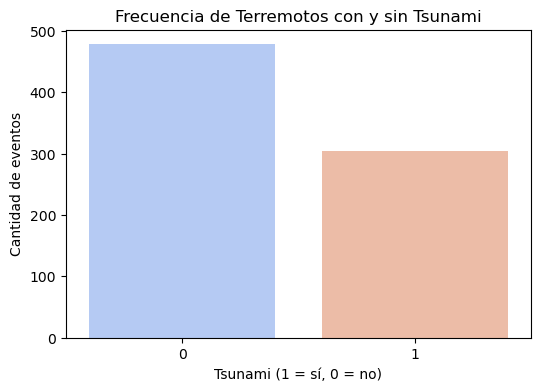

📊 Porcentaje de terremotos que generaron tsunami: 38.87%


In [4]:

# Distribución de magnitudes
plt.figure(figsize=(8,5))
sns.histplot(df['magnitude'], kde=True)
plt.title("Distribución de la magnitud")
plt.show()

# Distribución de profundidad
plt.figure(figsize=(8,5))
sns.histplot(df['depth'], kde=True)
plt.title("Distribución de la profundidad")
plt.show()

# Relación entre magnitud y tsunami
plt.figure(figsize=(7,5))
sns.boxplot(x=df['tsunami'], y=df['magnitude'])
plt.title("Magnitud según ocurrencia de tsunami")
plt.show()

# Mapa de correlación
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Mapa de correlación de variables")
plt.show()

#Frecuencia de eventos con y sin tsunami
plt.figure(figsize=(6,4))
sns.countplot(x='tsunami', data=df, hue='tsunami', palette='coolwarm', legend=False)
plt.title('Frecuencia de Terremotos con y sin Tsunami')
plt.xlabel('Tsunami (1 = sí, 0 = no)')
plt.ylabel('Cantidad de eventos')
plt.show()

# Porcentaje
tsunami_rate = df['tsunami'].mean() * 100
print(f"📊 Porcentaje de terremotos que generaron tsunami: {tsunami_rate:.2f}%")


# ----------------------------------------------------------
# 🤖 8. MODELADO PREDICTIVO
# ----------------------------------------------------------

In [6]:
# 📦 Importaciones necesarias
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 📊 Selección de variables predictoras
X = df[['magnitude', 'depth', 'latitude', 'longitude']]
y = df['tsunami']

# 🔀 División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ⚖️ Escalado de variables
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🤖 Modelo 1: Regresión Logística
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# 🌳 Modelo 2: Árbol de Decisión
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# 🧪 Evaluación de ambos modelos
models = {'Regresión Logística': log_model, 'Árbol de Decisión': tree_model}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n📊 Resultados del modelo: {name}")
    print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred))
    print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
    print("Reporte de clasificación:\n", classification_report(y_test, y_pred))




📊 Resultados del modelo: Regresión Logística
Exactitud (Accuracy): 0.5859872611464968
Matriz de confusión:
 [[80 16]
 [49 12]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.62      0.83      0.71        96
           1       0.43      0.20      0.27        61

    accuracy                           0.59       157
   macro avg       0.52      0.52      0.49       157
weighted avg       0.55      0.59      0.54       157


📊 Resultados del modelo: Árbol de Decisión
Exactitud (Accuracy): 0.6624203821656051
Matriz de confusión:
 [[89  7]
 [46 15]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.66      0.93      0.77        96
           1       0.68      0.25      0.36        61

    accuracy                           0.66       157
   macro avg       0.67      0.59      0.57       157
weighted avg       0.67      0.66      0.61       157



# ----------------------------------------------------------
# 📈 9. VISUALIZACIÓN DE RESULTADOS 
# ----------------------------------------------------------

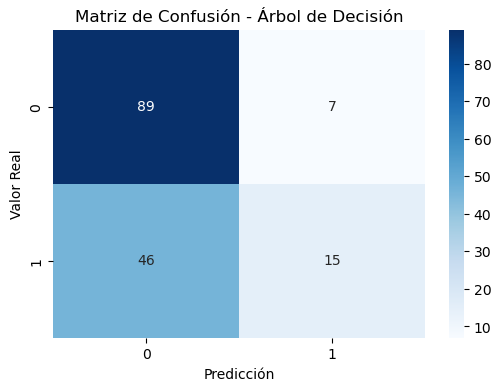


💬 ¿Qué significa?

✔️ Aciertos:
- 89 terremotos fueron correctamente clasificados como NO tsunamis.
- 15 terremotos fueron correctamente clasificados como SÍ tsunamis.

❌ Errores:
- 7 falsos positivos: el modelo predijo tsunami, pero no ocurrió.
- 46 falsos negativos: el modelo predijo que no habría tsunami, pero sí ocurrió.

🧠 Interpretación :
- El modelo es muy bueno identificando terremotos que NO generan tsunami (89 aciertos vs 7 errores).
- El modelo tiene más dificultad detectando los que SÍ generan tsunami, lo cual es normal porque la clase está desbalanceada.

⚠️ Punto importante:
- Los falsos negativos (tsunamis no detectados) son los errores más críticos y deben minimizarse en modelos reales de alerta temprana.


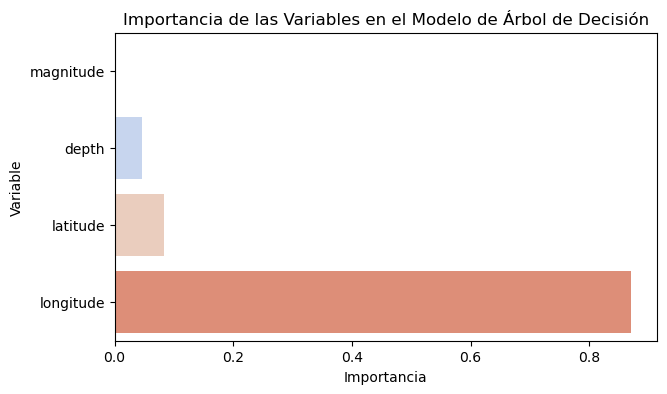

In [8]:

# Predicciones del mejor modelo (por ejemplo, el árbol de decisión)
y_pred_tree = tree_model.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

print("\n💬 ¿Qué significa?")

print("\n✔️ Aciertos:")
print("- 89 terremotos fueron correctamente clasificados como NO tsunamis.")
print("- 15 terremotos fueron correctamente clasificados como SÍ tsunamis.")

print("\n❌ Errores:")
print("- 7 falsos positivos: el modelo predijo tsunami, pero no ocurrió.")
print("- 46 falsos negativos: el modelo predijo que no habría tsunami, pero sí ocurrió.")

print("\n🧠 Interpretación :")
print("- El modelo es muy bueno identificando terremotos que NO generan tsunami (89 aciertos vs 7 errores).")
print("- El modelo tiene más dificultad detectando los que SÍ generan tsunami, lo cual es normal porque la clase está desbalanceada.")

print("\n⚠️ Punto importante:")
print("- Los falsos negativos (tsunamis no detectados) son los errores más críticos y deben minimizarse en modelos reales de alerta temprana.") 


# Importancia de las variables
importances = tree_model.feature_importances_
features = X.columns

plt.figure(figsize=(7,4))
sns.barplot(x=importances, y=features, hue=features, palette='coolwarm', dodge=False, legend=False)
plt.title('Importancia de las Variables en el Modelo de Árbol de Decisión')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()


# ----------------------------------------------------------
# 🗺️ 10. VISUALIZACIÓN GEOGRÁFICA DE TERREMOTOS Y TSUNAMIS
# ----------------------------------------------------------

In [ ]:
# Corregir las importaciones (redefinir cm correctamente)
import matplotlib.cm as cm
from matplotlib import colors
import folium
from IPython.display import display

# Normalizar colores por magnitud
norm = colors.Normalize(vmin=df["magnitude"].min(), vmax=df["magnitude"].max())
colormap = cm.ScalarMappable(norm=norm, cmap='RdYlBu_r')

# Crear mapa base
m = folium.Map(location=[0, 0], zoom_start=2, tiles="CartoDB positron")

# Agregar los puntos
for _, row in df.iterrows():
    color = colors.rgb2hex(colormap.to_rgba(row["magnitude"]))
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=row["magnitude"] * 1.5,
        color="black",
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=f"Magnitude: {row['magnitude']}, Depth: {row['depth']} km, Tsunami: {row['tsunami']}"
    ).add_to(m)

# Mostrar el mapa
display(m)


# 🧾 11. Resumen Final del Proyecto



### ✅ Pregunta de investigación:
> ¿Qué características sísmicas permiten predecir con mayor precisión si un terremoto tiene el potencial de generar un tsunami?

### 📊 Síntesis de resultados:

- **Análisis exploratorio:** la distribución de magnitudes mostró que la mayoría de los terremotos se ubican entre 6.5 y 7.5, mientras que la profundidad se concentra principalmente en eventos superficiales, que son los más relevantes para la generación de tsunamis.  
- **Correlaciones:** el mapa de correlación indicó que no existe una relación lineal fuerte entre las variables sísmicas y la ocurrencia de tsunamis. Esto sugiere que el fenómeno depende de una combinación de factores más compleja que una correlación directa.  
- **Desbalance del dataset:** el conteo de eventos reveló una proporción significativamente mayor de terremotos sin tsunami, lo cual afecta la capacidad de los modelos para predecir correctamente la clase minoritaria.  
- **Modelado predictivo:** aunque en la teoría la magnitud y la profundidad son factores clave en la generación de tsunamis, en este dataset el **Árbol de Decisión identificó la ubicación geográfica (longitud y latitud)** como las variables más influyentes en la clasificación. Esto se explica por la concentración de tsunamis en regiones específicas del Anillo de Fuego del Pacífico.  
- **Interpretación:** los resultados muestran que, para este conjunto de datos, la **distribución espacial** de los terremotos es más determinante que las características sísmicas aisladas. Sin embargo, variables como la profundidad y la magnitud continúan siendo relevantes desde una perspectiva geofísica.

### 🎯 Conclusión general:
El análisis demuestra que, dentro del dataset utilizado, la **ubicación geográfica del epicentro (especialmente la longitud)** es el factor que mejor permite diferenciar entre terremotos que generan y no generan tsunamis.  
Esto se debe a que los tsunamis reales se concentran en zonas tectónicamente activas.  
Si bien la magnitud y la profundidad son variables importantes en estudios sismológicos, su influencia en este modelo fue menor debido a la distribución particular de los datos y al desbalance entre clases.

Este análisis confirma que la **ciencia de datos** permite identificar patrones espaciales del riesgo y puede apoyar la toma de decisiones en sistemas de alerta temprana, siempre que se utilicen datos completos y equilibrados.

### 🧩 Logro de objetivos:
- ✅ Se realizó un análisis exploratorio del conjunto global.  
- ✅ Se evaluaron distribuciones, correlaciones y patrones espaciales.  
- ✅ Se identificaron las variables más influyentes en el modelo predictivo.  
- ✅ Se construyeron y evaluaron modelos de clasificación binaria.  
- ✅ Se interpretaron los resultados con base en evidencia gráfica y estadística.  
- ✅ Se formularon conclusiones fundamentadas.

### 🛠️ Recomendaciones:
- Incorporar variables geofísicas adicionales como tipo de falla, mecanismo focal y distancia a la costa.  
- Balancear el dataset para mejorar la detección de tsunamis reales.  
- Probar modelos más avanzados (Random Forest, XGBoost) que manejen mejor datos desbalanceados.  
- Continuar desarrollando mapas de riesgo basados en ubicación y profundidad.  
- Integrar modelos predictivos como herramienta complementaria en sistemas de alerta temprana.

---


---
